In [1]:
import os, torch
import pandas as pd
import numpy as np
from pathlib import Path
from pathlib import PureWindowsPath
import matplotlib.pyplot as plt

## CNN-8 TimeEstimator errors

In [34]:
errors = pd.read_csv("/projects/net_contrast_classification/contrast_phase/DeepLClassifiers/Time_interval/results/DeepTimeEstimator_CNN8_pred_intervals.csv")
errors

,patient_id,date,true_interval,pred_interval,sigmoid_scores,error
0,NKI-d23231-00-0010,2007-02-13,40.000000,44.271774,0.491909,4.271774
1,NKI-d23231-00-0010,2007-02-13,45.000000,50.092167,0.556580,5.092167
2,NKI-d23231-00-0035,2015-12-12,24.500000,32.996479,0.366628,8.496479
3,NKI-d23231-00-0037,2008-10-01,54.890228,60.381489,0.670905,5.491261
4,NKI-d23231-00-0037,2011-03-02,36.391998,48.896870,0.543299,12.504871
...,...,...,...,...,...,...
406,NKI-d23231-00-0878,2023-06-05,37.094002,31.966663,0.355185,5.127338
407,NKI-d23231-00-0887,2021-08-25,32.421638,41.362347,0.459582,8.940708
408,NKI-d23231-00-0887,2022-07-21,32.295422,44.558857,0.495098,12.263435
409,NKI-d23231-00-0887,2023-05-24,31.577999,32.327702,0.359197,0.749702


In [3]:
paired_data = pd.read_csv("/projects/net_contrast_classification/contrast_phase/Preprocessing/Time_interval_data/paired_preprocessed_data.csv")
paired_data

,SubjectKeyRadiology,ExamDate,arterial_file,portal_file,arterial_organs,portal_organs,arterial_timing,portal_timing,time_interval,split,output_dir,base_name_raw,dups_count,base_name,output_path
0,NKI-d23231-00-0002,2015-12-01,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Too Late,Too Early,0.00519,train,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0002_2015-12-01,0,NKI-d23231-00-0002_2015-12-01,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
1,NKI-d23231-00-0005,2010-02-04,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Too Early,Just Right,53.64779,train,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0005_2010-02-04,0,NKI-d23231-00-0005_2010-02-04,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
2,NKI-d23231-00-0005,2012-06-18,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Too Early,Too Early,33.40000,train,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0005_2012-06-18,0,NKI-d23231-00-0005_2012-06-18,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
3,NKI-d23231-00-0005,2022-05-11,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Just Right,Just Right,30.84280,train,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0005_2022-05-11,0,NKI-d23231-00-0005_2022-05-11,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
4,NKI-d23231-00-0005,2022-10-17,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Just Right,Just Right,32.75200,train,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0005_2022-10-17,0,NKI-d23231-00-0005_2022-10-17,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2067,NKI-d23231-00-0887,2023-05-24,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Just Right,Just Right,31.57800,test,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0887_2023-05-24,0,NKI-d23231-00-0887_2023-05-24,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
2068,NKI-d23231-00-0887,2023-08-30,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Just Right,Just Right,28.90000,test,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0887_2023-08-30,0,NKI-d23231-00-0887_2023-08-30,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
2069,NKI-d23231-00-0888,2022-04-20,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Just Right,Just Right,31.78189,train,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0888_2022-04-20,0,NKI-d23231-00-0888_2022-04-20,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
2070,NKI-d23231-00-0888,2023-04-24,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Just Right,Just Right,34.57700,train,/mnt/rhea/data_private

In [8]:
original_data = pd.read_csv("/projects/net_contrast_classification/contrast_phase/data/cleaned_data/final_data.csv")

In [12]:
patients_all = original_data["SubjectKeyRadiology"].nunique()
patients_both_phases = paired_data["SubjectKeyRadiology"].nunique()
print(
    f"Number of unique patient ids in the data: {patients_all}\n",
    f"Number of patient ids that have both AP and PVP scans: {patients_both_phases}"
)


Number of unique patient ids in the data: 656
 Number of patient ids that have both AP and PVP scans: 475


In [13]:
seg_data = pd.read_csv("/projects/net_contrast_classification/contrast_phase/Preprocessing/Segmentation_data/full_pairs.csv")
seg_data["SubjectKeyRadiology"].nunique()

850

In [20]:
seg_data_pairs = seg_data[seg_data["split"] != "inference"]
seg_data_pairs["SubjectKeyRadiology"].nunique()
seg_data_pairs["orig_patient_id"] = (
    seg_data_pairs["SubjectKeyRadiology"]
    .str.split("_")
    .str[0]
)

In [22]:
seg_data_pairs["orig_patient_id"].nunique()

475

In [32]:
seg_data_pairs_diff_lesion = seg_data_pairs[seg_data_pairs["lesion_visible_both"] == False]
seg_data_pairs_diff_lesion["orig_patient_id"].nunique()

112

In [35]:
errors = errors.merge(paired_data,
                      left_on=["patient_id","date"],
                      right_on=["SubjectKeyRadiology","ExamDate"],
                      how="left")
errors

,patient_id,date,true_interval,pred_interval,sigmoid_scores,error,SubjectKeyRadiology,ExamDate,arterial_file,portal_file,...,portal_organs,arterial_timing,portal_timing,time_interval,split,output_dir,base_name_raw,dups_count,base_name,output_path
0,NKI-d23231-00-0010,2007-02-13,40.000000,44.271774,0.491909,4.271774,NKI-d23231-00-0010,2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Too Early,Just Right,40.00000,test,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0010_2007-02-13,0,NKI-d23231-00-0010_2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
1,NKI-d23231-00-0010,2007-02-13,40.000000,44.271774,0.491909,4.271774,NKI-d23231-00-0010,2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Too Early,Just Right,368.00000,test,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0010_2007-02-13,1,NKI-d23231-00-0010_2007-02-13_1,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
2,NKI-d23231-00-0010,2007-02-13,40.000000,44.271774,0.491909,4.271774,NKI-d23231-00-0010,2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Too Early,Just Right,45.00000,test,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0010_2007-02-13,2,NKI-d23231-00-0010_2007-02-13_2,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
3,NKI-d23231-00-0010,2007-02-13,45.000000,50.092167,0.556580,5.092167,NKI-d23231-00-0010,2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Too Early,Just Right,40.00000,test,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0010_2007-02-13,0,NKI-d23231-00-0010_2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
4,NKI-d23231-00-0010,2007-02-13,45.000000,50.092167,0.556580,5.092167,NKI-d23231-00-0010,2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Too Early,Just Right,368.00000,test,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0010_2007-02-13,1,NKI-d23231-00-0010_2007-02-13_1,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,NKI-d23231-00-0878,2023-06-05,37.094002,31.966663,0.355185,5.127338,NKI-d23231-00-0878,2023-06-05,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Just Right,Just Right,37.09400,test,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0878_2023-06-05,0,NKI-d23231-00-0878_2023-06-05,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
567,NKI-d23231-00-0887,2021-08-25,32.421638,41.362347,0.459582,8.940708,NKI-d23231-00-0887,2021-08-25,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Just Right,Too Early,32.42164,test,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0887_2021-08-25,0,NKI-d23231-00-0887_2021-08-25,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
568,NKI-d23231-00-0887,2022-07-21,32.295422,44.558857,0.495098,12.263435,NKI-d23231-00-0887,2022-07-21,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Just Right,Just Right,32.29542,test,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0887_2022-07-21,0,NKI-d23231-00-0887_2022-07-21,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
569,NKI-d23231-00-0887,2023-05-24,31.577

In [5]:
big_errors = errors[errors.error >= 10]
big_errors[["SubjectKeyRadiology","ExamDate",  "output_path", "arterial_timing","portal_timing", "time_interval", "pred_interval", "error"]]

,SubjectKeyRadiology,ExamDate,output_path,arterial_timing,portal_timing,time_interval,pred_interval,error
8,NKI-d23231-00-0037,2011-03-02,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,Just Right,Just Right,36.39200,48.896870,12.504871
13,NKI-d23231-00-0045,2014-01-29,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,Just Right,Just Right,21.05000,37.764076,16.714077
14,NKI-d23231-00-0045,2014-01-29,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,Just Right,Just Right,37.20000,37.764076,16.714077
28,NKI-d23231-00-0062,2012-10-26,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,Just Right,Just Right,29.85000,40.557533,10.707533
47,NKI-d23231-00-0062,2015-03-25,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,Just Right,Just Right,30.50000,41.504841,11.004841
...,...,...,...,...,...,...,...,...
537,NKI-d23231-00-0772,2021-01-21,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,Just Right,Just Right,57.89158,41.886875,16.004704
546,NKI-d23231-00-0799,2021-11-10,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,Just Right,Just Right,31.76439,50.321251,18.556860
556,NKI-d23231-00-0864,2022-03-01,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,Just Right,Just Right,31.54619,47.249428,15.703238
559,NKI-d23231-00-0869,2022-05-04,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,Just Right,Just Right,29.62543,39.697945,10.072515


/tmp/ipykernel_2171180/3966756970.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(row["output_path"], map_location="cpu")


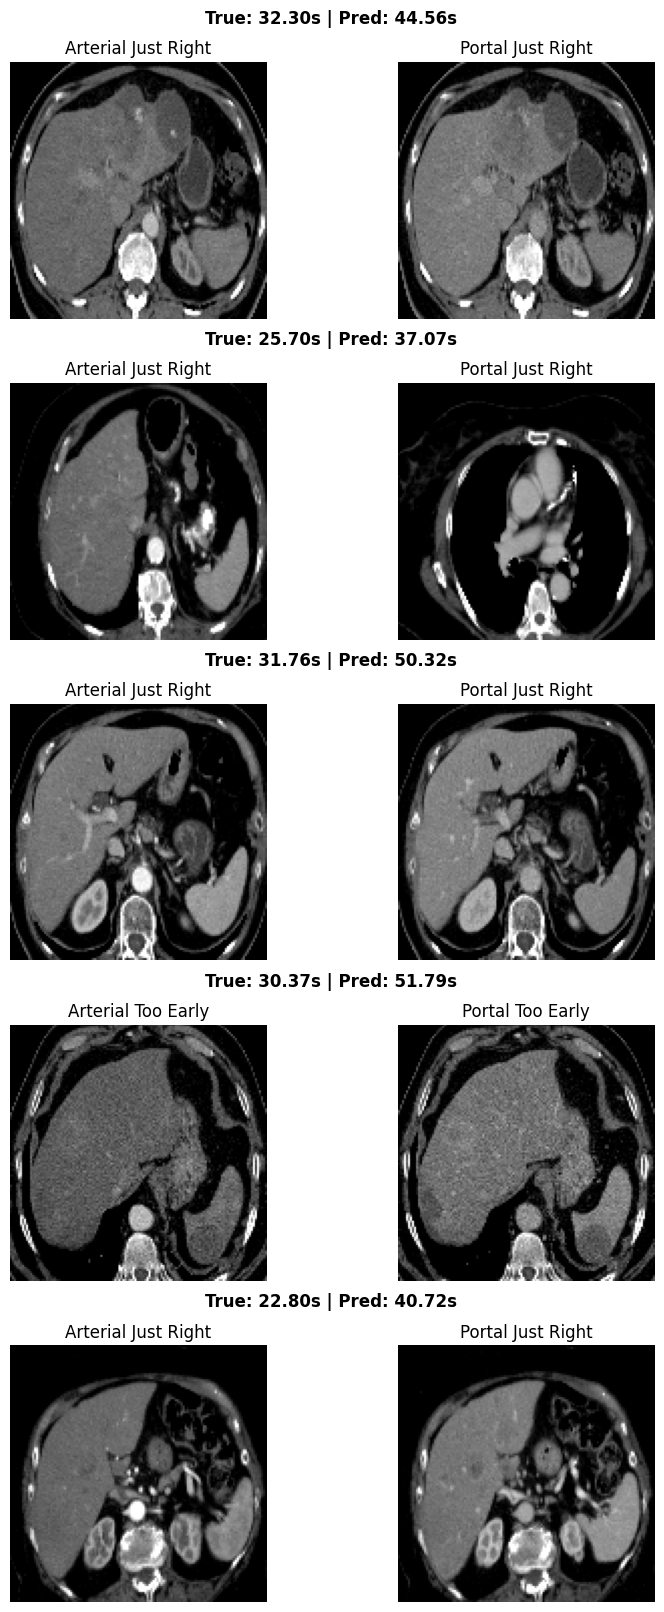

In [55]:
# sample 5 rows
df = big_errors[big_errors["time_interval"] < 50.00]
sample = df.sample(5, replace=False)

fig, axes = plt.subplots(5, 2, figsize=(10, 20))

for i, (_, row) in enumerate(sample.iterrows()):

    data = torch.load(row["output_path"], map_location="cpu")

    arterial = data["arterial_image"]
    portal = data["portal_image"]

    # assume shape [C, H, W, D] or [H, W, D]
    if arterial.ndim == 4:
        arterial_img = arterial[0]
        portal_img = portal[0]
    else:
        arterial_img = arterial
        portal_img = portal

    # take middle slice along depth
    mid_a = arterial_img.shape[-1] // 2
    mid_p = portal_img.shape[-1] // 2

    ax_a = axes[i, 0]
    ax_p = axes[i, 1]

    ax_a.imshow(np.rot90(arterial_img[:, :, 100], k=1), cmap="gray")
    ax_a.set_title(f"Arterial {row["arterial_timing"]}")
    ax_a.axis("off")

    ax_p.imshow(np.rot90(portal_img[:, :, 100], k=1), cmap="gray")
    ax_p.set_title(f"Portal {row["portal_timing"]}")
    ax_p.axis("off")

    axes[i, 0].annotate(
    f"True: {row['time_interval']:.2f}s | Pred: {row['pred_interval']:.2f}s",
    xy=(1.25, 1.15),
    xycoords="axes fraction",
    ha="center",
    fontsize=12,
    fontweight="bold")

plt.subplots_adjust(hspace=0.25, wspace=0.00001)
plt.show()

In [56]:
small_errors = errors[errors.error <= 6]
small_errors[["SubjectKeyRadiology","ExamDate",  "output_path", "arterial_timing","portal_timing", "time_interval", "pred_interval", "error"]]

,SubjectKeyRadiology,ExamDate,output_path,arterial_timing,portal_timing,time_interval,pred_interval,error
0,NKI-d23231-00-0010,2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,Too Early,Just Right,40.000,44.271774,4.271774
1,NKI-d23231-00-0010,2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,Too Early,Just Right,368.000,44.271774,4.271774
2,NKI-d23231-00-0010,2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,Too Early,Just Right,45.000,44.271774,4.271774
3,NKI-d23231-00-0010,2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,Too Early,Just Right,40.000,50.092167,5.092167
4,NKI-d23231-00-0010,2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,Too Early,Just Right,368.000,50.092167,5.092167
...,...,...,...,...,...,...,...,...
564,NKI-d23231-00-0876,2023-09-22,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,Just Right,Just Right,36.143,30.987690,5.155312
565,NKI-d23231-00-0878,2023-03-17,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,Just Right,Just Right,34.862,32.094772,2.767227
566,NKI-d23231-00-0878,2023-06-05,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,Just Right,Just Right,37.094,31.966663,5.127338
569,NKI-d23231-00-0887,2023-05-24,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,Just Right,Just Right,31.578,32.327702,0.749702


/tmp/ipykernel_2171180/304032861.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(row["output_path"], map_location="cpu")


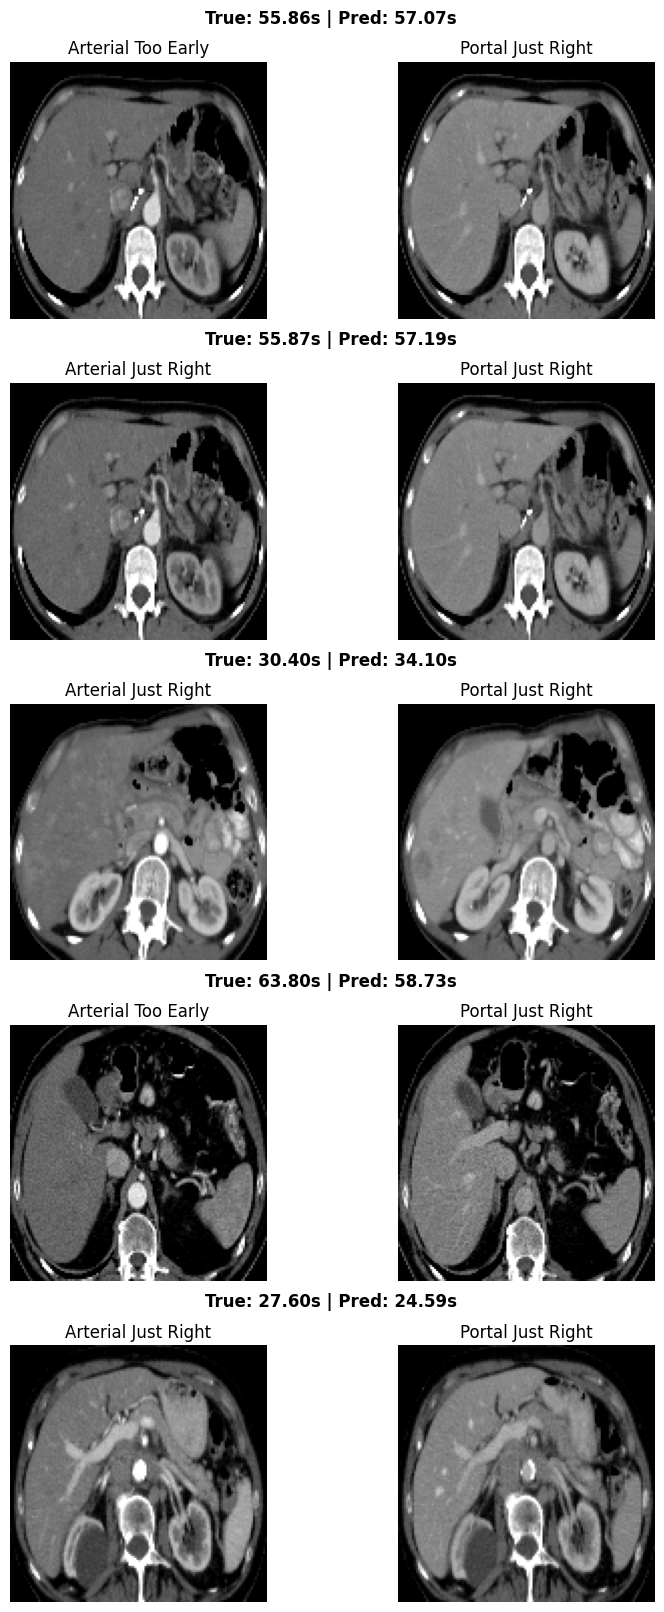

In [59]:
# sample 5 rows
df = small_errors
sample = df.sample(5, replace=False)

fig, axes = plt.subplots(5, 2, figsize=(10, 20))

for i, (_, row) in enumerate(sample.iterrows()):

    data = torch.load(row["output_path"], map_location="cpu")

    arterial = data["arterial_image"]
    portal = data["portal_image"]

    # assume shape [C, H, W, D] or [H, W, D]
    if arterial.ndim == 4:
        arterial_img = arterial[0]
        portal_img = portal[0]
    else:
        arterial_img = arterial
        portal_img = portal

    # take middle slice along depth
    mid_a = arterial_img.shape[-1] // 2
    mid_p = portal_img.shape[-1] // 2

    ax_a = axes[i, 0]
    ax_p = axes[i, 1]

    ax_a.imshow(np.rot90(arterial_img[:, :, 100], k=1), cmap="gray")
    ax_a.set_title(f"Arterial {row["arterial_timing"]}")
    ax_a.axis("off")

    ax_p.imshow(np.rot90(portal_img[:, :, 100], k=1), cmap="gray")
    ax_p.set_title(f"Portal {row["portal_timing"]}")
    ax_p.axis("off")

    axes[i, 0].annotate(
    f"True: {row['time_interval']:.2f}s | Pred: {row['pred_interval']:.2f}s",
    xy=(1.25, 1.15),
    xycoords="axes fraction",
    ha="center",
    fontsize=12,
    fontweight="bold")

plt.subplots_adjust(hspace=0.25, wspace=0.00001)
plt.show()

## CNN-8 TimeRegressor errors

In [60]:
errors = pd.read_csv("/projects/net_contrast_classification/contrast_phase/DeepLClassifiers/Time_interval/results/DeepTimeRegressor_CNN8_pred_intervals.csv")
errors

,patient_id,date,true_interval,pred_interval,sigmoid_scores,error
0,NKI-d23231-00-0010,2007-02-13,40.000000,41.218410,NaN,1.218410
1,NKI-d23231-00-0010,2007-02-13,45.000000,48.136417,NaN,3.136417
2,NKI-d23231-00-0035,2015-12-12,24.500000,33.465549,NaN,8.965549
3,NKI-d23231-00-0037,2008-10-01,54.890228,56.160053,NaN,1.269825
4,NKI-d23231-00-0037,2011-03-02,36.391998,52.338833,NaN,15.946835
...,...,...,...,...,...,...
406,NKI-d23231-00-0878,2023-06-05,37.094002,41.137783,NaN,4.043781
407,NKI-d23231-00-0887,2021-08-25,32.421638,33.739368,NaN,1.317730
408,NKI-d23231-00-0887,2022-07-21,32.295422,35.690197,NaN,3.394775
409,NKI-d23231-00-0887,2023-05-24,31.577999,29.204594,NaN,2.373405


In [61]:
errors = errors.merge(paired_data,
                      left_on=["patient_id","date"],
                      right_on=["SubjectKeyRadiology","ExamDate"],
                      how="left")
errors

,patient_id,date,true_interval,pred_interval,sigmoid_scores,error,SubjectKeyRadiology,ExamDate,arterial_file,portal_file,...,portal_organs,arterial_timing,portal_timing,time_interval,split,output_dir,base_name_raw,dups_count,base_name,output_path
0,NKI-d23231-00-0010,2007-02-13,40.000000,41.218410,NaN,1.218410,NKI-d23231-00-0010,2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Too Early,Just Right,40.00000,test,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0010_2007-02-13,0,NKI-d23231-00-0010_2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
1,NKI-d23231-00-0010,2007-02-13,40.000000,41.218410,NaN,1.218410,NKI-d23231-00-0010,2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Too Early,Just Right,368.00000,test,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0010_2007-02-13,1,NKI-d23231-00-0010_2007-02-13_1,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
2,NKI-d23231-00-0010,2007-02-13,40.000000,41.218410,NaN,1.218410,NKI-d23231-00-0010,2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Too Early,Just Right,45.00000,test,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0010_2007-02-13,2,NKI-d23231-00-0010_2007-02-13_2,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
3,NKI-d23231-00-0010,2007-02-13,45.000000,48.136417,NaN,3.136417,NKI-d23231-00-0010,2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Too Early,Just Right,40.00000,test,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0010_2007-02-13,0,NKI-d23231-00-0010_2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
4,NKI-d23231-00-0010,2007-02-13,45.000000,48.136417,NaN,3.136417,NKI-d23231-00-0010,2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Too Early,Just Right,368.00000,test,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0010_2007-02-13,1,NKI-d23231-00-0010_2007-02-13_1,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,NKI-d23231-00-0878,2023-06-05,37.094002,41.137783,NaN,4.043781,NKI-d23231-00-0878,2023-06-05,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Just Right,Just Right,37.09400,test,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0878_2023-06-05,0,NKI-d23231-00-0878_2023-06-05,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
567,NKI-d23231-00-0887,2021-08-25,32.421638,33.739368,NaN,1.317730,NKI-d23231-00-0887,2021-08-25,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Just Right,Too Early,32.42164,test,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0887_2021-08-25,0,NKI-d23231-00-0887_2021-08-25,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
568,NKI-d23231-00-0887,2022-07-21,32.295422,35.690197,NaN,3.394775,NKI-d23231-00-0887,2022-07-21,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Just Right,Just Right,32.29542,test,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0887_2022-07-21,0,NKI-d23231-00-0887_2022-07-21,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
569,NKI-d23231-00-0887,2023-05-24,31.577999,29.204594,NaN,2.373405,NKI-d23231-00-

/tmp/ipykernel_2171180/1299179893.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(row["output_path"], map_location="cpu")


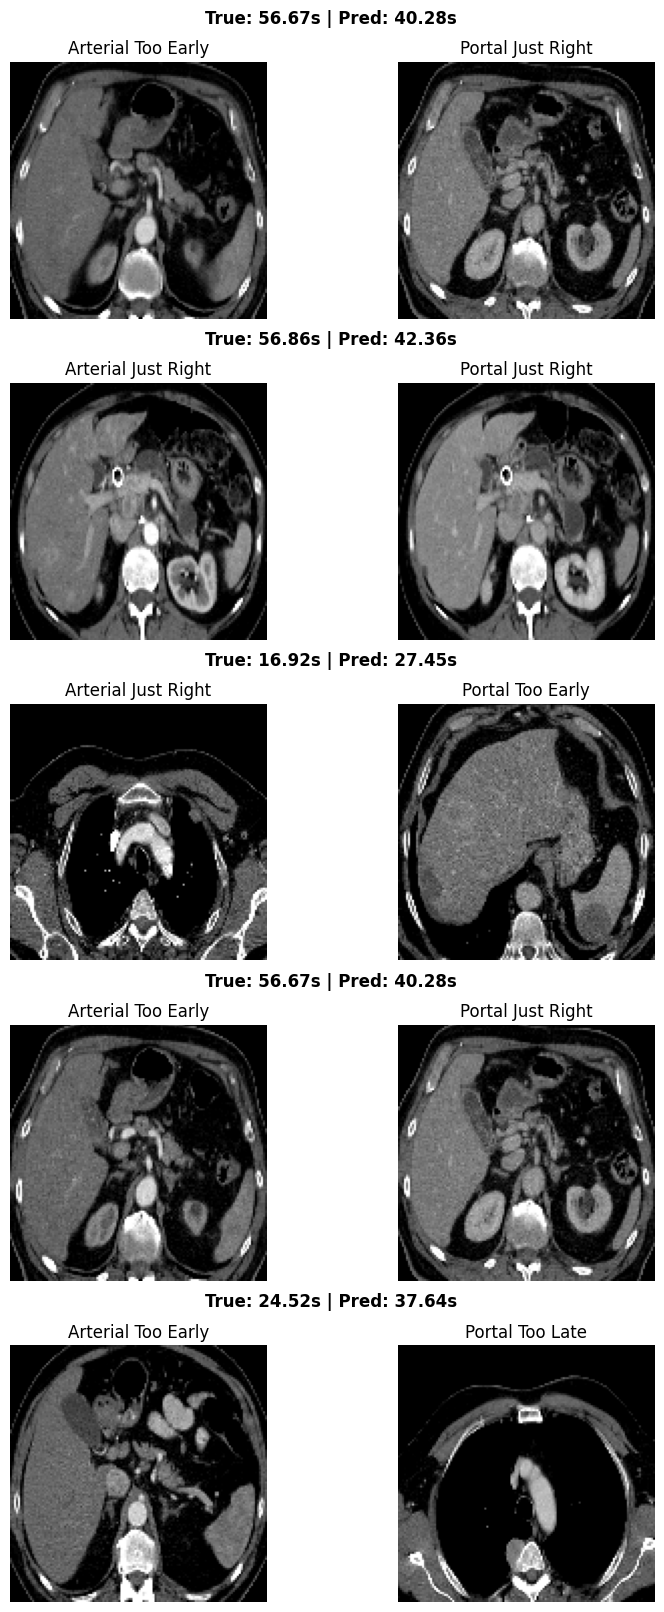

In [75]:
# sample 5 rows
# small_errors = errors[errors["error"] <= 6.00]
big_errors = errors[errors["error"] >= 10.00]


df = big_errors
sample = df.sample(5, replace=False)

fig, axes = plt.subplots(5, 2, figsize=(10, 20))

for i, (_, row) in enumerate(sample.iterrows()):

    data = torch.load(row["output_path"], map_location="cpu")

    arterial = data["arterial_image"]
    portal = data["portal_image"]

    # assume shape [C, H, W, D] or [H, W, D]
    if arterial.ndim == 4:
        arterial_img = arterial[0]
        portal_img = portal[0]
    else:
        arterial_img = arterial
        portal_img = portal

    # take middle slice along depth
    mid_a = arterial_img.shape[-1] // 2
    mid_p = portal_img.shape[-1] // 2

    ax_a = axes[i, 0]
    ax_p = axes[i, 1]

    ax_a.imshow(np.rot90(arterial_img[:, :, 100], k=1), cmap="gray")
    ax_a.set_title(f"Arterial {row["arterial_timing"]}")
    ax_a.axis("off")

    ax_p.imshow(np.rot90(portal_img[:, :, 100], k=1), cmap="gray")
    ax_p.set_title(f"Portal {row["portal_timing"]}")
    ax_p.axis("off")

    axes[i, 0].annotate(
    f"True: {row['time_interval']:.2f}s | Pred: {row['pred_interval']:.2f}s",
    xy=(1.25, 1.15),
    xycoords="axes fraction",
    ha="center",
    fontsize=12,
    fontweight="bold")

plt.subplots_adjust(hspace=0.25, wspace=0.00001)
plt.show()

In [77]:
len(original_data)

8335